# Running diagnostics for dummy run

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
epoch = "0004"

with h5py.File("./run_export/validation_data.h5", 'r') as fp:
    print(fp.keys())
    print(fp[f'epoch_{epoch}'].keys())
    print(fp[f'epoch_{epoch}']['network_output'])
    print(fp[f'epoch_{epoch}']['network_target'])
    print(fp[f'epoch_{epoch}']['signal_params'])

    network_output = fp[f'epoch_{epoch}']['network_output'][:]
    network_target = fp[f'epoch_{epoch}']['network_target'][:]

<KeysViewHDF5 ['epoch_0000', 'epoch_0004']>
<KeysViewHDF5 ['network_output', 'network_target', 'signal_params']>
<HDF5 dataset "network_output": shape (1562, 128, 3), type "<f2">
<HDF5 dataset "network_target": shape (1562, 128, 3), type "<f4">
<HDF5 dataset "signal_params": shape (1562, 64, 25), type "<f4">


In [3]:
network_output = np.vstack(network_output)
network_target = np.vstack(network_target)

In [16]:
noise_idx = np.argwhere(network_target[:,-1] == 0.0).flatten()
signal_idx = np.argwhere(network_target[:,-1] == 1.0).flatten()

In [26]:
signal_rs = network_output[:,0][signal_idx]
noise_rs = network_output[:,0][noise_idx]

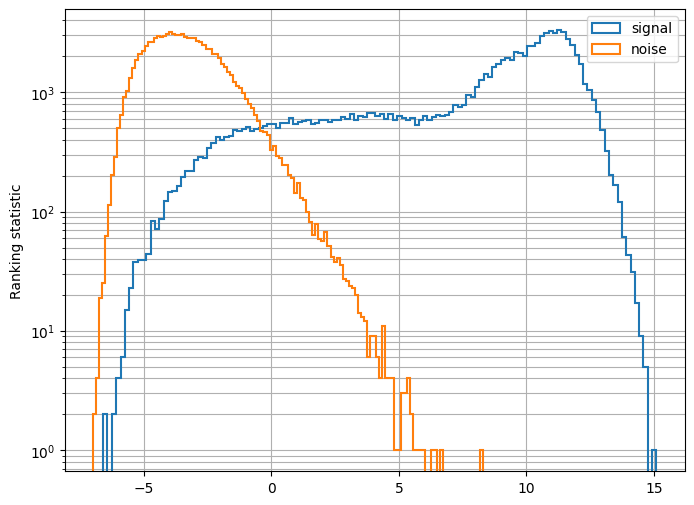

In [25]:
plt.figure(figsize=(8, 6))
plt.hist(network_output[:,0][signal_idx], bins=128, label='signal', histtype='step', linewidth=1.5)
plt.hist(network_output[:,0][noise_idx], bins=128, label='noise', histtype='step', linewidth=1.5)
plt.grid(True, which='both')
plt.yscale('log')
plt.ylabel('Frequency')
plt.ylabel('Ranking statistic')
plt.legend()
plt.show()

/tmp/ipykernel_1272593/892809595.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


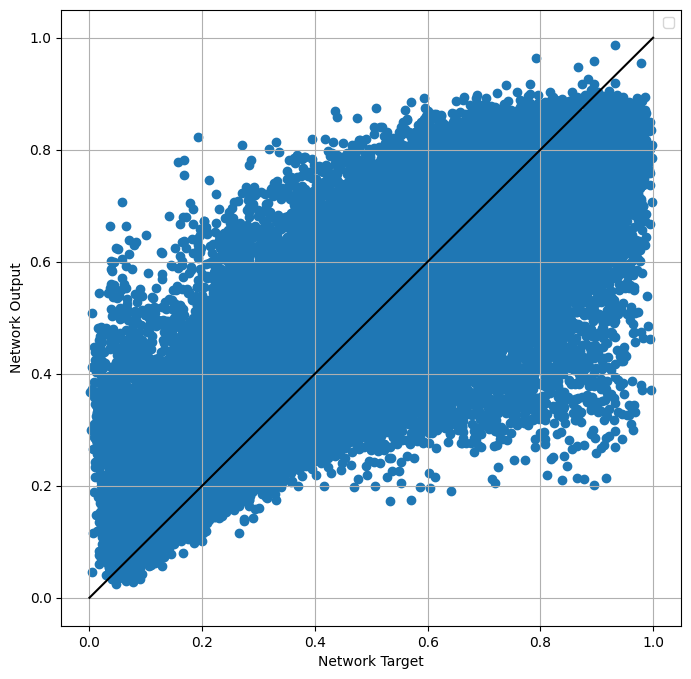

In [33]:
plt.figure(figsize=(8, 8))
plt.scatter(network_target[:,1][signal_idx], network_output[:,2][signal_idx])
plt.grid(True, which='both')
plt.ylabel('Network Output')
plt.xlabel('Network Target')
plt.plot([0,1], [0,1], color='k', linewidth=1.5, zorder=999)
plt.legend()
plt.show()

In [3]:
with h5py.File("./run_export/losses.h5", 'r') as fp:
    print(fp.keys())
    print(fp['training']['loss'][:])
    print(fp['validation']['loss'][:])

<KeysViewHDF5 ['training', 'validation']>
[[0.23810674 0.2338182  0.01429494]
 [0.18210487 0.1795749  0.00843397]
 [0.16982411 0.16756794 0.00751867]
 [0.16263752 0.16053878 0.0069945 ]
 [0.15887746 0.15686087 0.00671928]]
[[0.20924902 0.20655416 0.00898282]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.17145345 0.16952676 0.00642223]]
